In [63]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utilities as ut
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture


In [64]:
def get_halo_center(part, halt, sim, sim_dir, snapshot):
    # check if centering should be on dm halo
    sim_codes = sim_dir + "simulation_codes.json"
    with open(sim_codes) as sim_json:
        sim_data = json.load(sim_json)
    main_halo_tid = sim_data[sim]["halo"]

    not_host_snap_lst = gc_utils.get_different_snap_lst(main_halo_tid, halt, sim, sim_dir)

    # is the MW progenitor is the main host at this snapshot
    is_main_host = snapshot not in not_host_snap_lst

    halt_center_snap_lst = sim_data[sim]["dm_center"]
    use_dm_center = snapshot in halt_center_snap_lst

    # if the halo is not the host at this snapshot or it has been flagged to use dm center at this snapshot
    if (not is_main_host) or (use_dm_center):
        # get MW progenitor halo details at this snapshot
        halo_tid = gc_utils.get_main_prog_at_snap(halt, main_halo_tid, snapshot)

        if use_dm_center:
            halo_detail_dict = gc_utils.get_dm_halo_details(part, halt, halo_tid, snapshot, True)
        else:
            halo_detail_dict = gc_utils.get_halo_details(part, halt, halo_tid, snapshot)

        return_dict = {"use_host_prop": False, "halo_details": halo_detail_dict}

    else:
        return_dict = {"use_host_prop": True}

    return return_dict


def get_mass_ratios(halt, part, sim: str, sim_dir: str, snapshot: int, r_50: float):
    host_return_dict = get_halo_center(part, halt, sim, sim_dir, snapshot)

    # stellar_mass
    if host_return_dict["use_host_prop"]:
        star_msk = part["star"].prop("host.distance.principal.total") < r_50
        dark_msk = part["dark"].prop("host.distance.principal.total") < r_50
    else:
        halo_detail_dict = host_return_dict["halo_details"]
        star_msk = (
            ut.particle.get_distances_wrt_center(
                part,
                species=["star"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=True,
            )
            < r_50
        )

        dark_msk = (
            ut.particle.get_distances_wrt_center(
                part,
                species=["dark"],
                center_position=halo_detail_dict["position"],
                rotation=halo_detail_dict["rotation"],
                coordinate_system="cartesian",
                total_distance=True,
            )
            < r_50
        )

    star_mass = part["star"]["mass"][star_msk]
    dark_mass = part["dark"]["mass"][dark_msk]

    return np.sum(star_mass) / np.sum(dark_mass)


In [65]:
sim = "m12m"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

In [66]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == 600]["time_Gyr"].values[0])
pub_times = np.array(pub_data["time_Gyr"])
pub_snaps = np.array(pub_data["index"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

In [67]:
halt = gc_utils.get_halo_tree(sim, sim_dir, species=["star"])

Retrieving Halo Tree.....................: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [06:31<00:00, 391.70s/it]


In [68]:
snp_lst = pub_snaps[(pub_snaps > 45) & (pub_snaps <= 590)]
tim_lst = pub_times[(pub_snaps > 45) & (pub_snaps <= 590)]
host_tid = sim_data[sim]["halo"]

r50s = []
for snp in snp_lst:
    tid = gc_utils.get_halo_prog_at_snap(halt, host_tid, snp)
    idx = np.where(halt["tid"] == tid)[0][0]
    r50s.append(halt["star.radius.50"][idx])

In [69]:
rats = []
for snp, r50 in zip(snp_lst, r50s):
    part = gc_utils.open_snapshot(snp, fire_dir, ["star", "dark"])
    rat = get_mass_ratios(halt, part, sim, sim_dir, snp, r50)
    rats.append(rat)

Retrieving Snapshot 590..................: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:56<00:00, 56.69s/it]


Text(0, 0.5, 'M$_{star}$ (R < R$_{star, 50}$) / M$_{DM}$ (R < R$_{star, 50}$)')

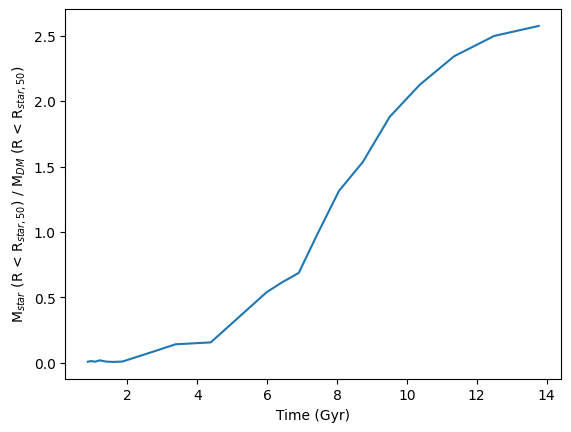

In [70]:
plt.plot(tim_lst, rats)
plt.xlabel("Time (Gyr)")
plt.ylabel(r"M$_{star}$ (R < R$_{star, 50}$) / M$_{DM}$ (R < R$_{star, 50}$)")